#**Projeto Guiado (Parte 2): Semana 15**
##**Dataset de Estilo de Vida e Previsão de Estresse de Estudantes**

##**1. Introdução**

O estresse é um dos fatores que mais afetam o desempenho acadêmico dos estudantes.
Diversos aspectos do cotidiano, como horas de estudo, qualidade do sono, uso de redes sociais, presença nas aulas e apoio familiar podem influenciar diretamente esse nível de estresse.

O objetivo deste projeto é construir modelos de Machine Learning capazes de prever se um estudante apresenta alto nível de estresse (Stress_Level = 1) ou baixo nível de estresse (Stress_Level = 0).

Para isso serão comparados diferentes algoritmos de classificação e, ao final, será escolhido aquele que apresentar o melhor desempenho.

##**2. Importação das Bibliotecas**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [8]:
df = pd.read_csv("student-lifestyle-and-stress-dataset.csv")
# Removendo valores ausentes antes do processamento
df.dropna(inplace=True)
df.head()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1
7,college,6.357065,2.827955,6.198479,74.180341,7.0,8.0,6.0,0


##**3. Descrição do Dataset**

| Variável | Descrição |
| :--- | :--- |
| Student_Type | school ou college |
| Sleep_Hours | Horas de sono |
| Study_Hours | Horas de estudo |
| Social_Media_Hours | Tempo em redes sociais |
| Attendance | Frequência |
| Exam_Pressure | Pressão com provas |
| Family_Support | Apoio familiar |
| Month | Mês |
| Stress_Level | Variável alvo |

##**4. Pré-processamento**

Como há uma variável categórica (Student_Type):

In [3]:
encoder = LabelEncoder()

df["Student_Type"] = encoder.fit_transform(df["Student_Type"])

Depois:

In [12]:
# Garantindo que X e y usem o dataframe sem NaNs
X = df.drop("Stress_Level", axis=1)
y = df["Stress_Level"]

Separação:

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Escalonamento:

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##**5. Modelos Testados**

###**Modelo 1: Regressão Logística**

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

# Garantindo que não existam NaNs nos dados de treino/teste
imputer = SimpleImputer(strategy='median')
X_train_clean = imputer.fit_transform(X_train)
X_test_clean = imputer.transform(X_test)

lr = LogisticRegression()
lr.fit(X_train_clean, y_train)

pred_lr = lr.predict(X_test_clean)

###**Modelo 2: Árvore de Decisão**

In [14]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

###**Modelo 3: Random Forest**

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

###**Modelo 4: KNN**

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

# Usando os dados limpos pelo Imputer para evitar o erro de NaN
knn.fit(X_train_clean, y_train)

pred_knn = knn.predict(X_test_clean)

##**6. Comparação**

In [19]:
def avaliar(y_true, pred):

    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "F1": f1_score(y_true, pred)
    }

In [20]:
resultados = pd.DataFrame({

"Logistic Regression": avaliar(y_test,pred_lr),
"Decision Tree": avaliar(y_test,pred_tree),
"Random Forest": avaliar(y_test,pred_rf),
"KNN": avaliar(y_test,pred_knn)

}).T

resultados

,Accuracy,Precision,Recall,F1
Logistic Regression,0.815490,0.744038,0.601929,0.665482
Decision Tree,0.746471,0.584299,0.583923,0.584111
Random Forest,0.813529,0.750415,0.581994,0.655560
KNN,0.779608,0.675918,0.532476,0.595683


##**7. Melhor modelo**

Foram avaliados quatro algoritmos de classificação: Regressão Logística, Árvore de Decisão, Random Forest e KNN.

A **Regressão Logística** apresentou o melhor desempenho geral, obtendo 81,55% de acurácia, além do maior Recall (60,19%) e do maior F1-Score (66,55%) entre os modelos avaliados. Embora a Random Forest tenha alcançado uma precisão ligeiramente superior, seu F1-Score foi inferior, indicando um equilíbrio menos favorável entre precisão e recall.

Dessa forma, a **Regressão Logística** foi escolhida como o modelo final deste projeto por apresentar o melhor desempenho global e maior capacidade de generalização para a predição do nível de estresse dos estudantes.

##**8. Otimização (GridSearch)**

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

grid = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

# Utilizando X_train_clean (sem NaNs) em vez de X_train
grid.fit(X_train_clean, y_train)

print("Melhores parâmetros:", grid.best_params_)
print("Melhor F1:", grid.best_score_)

Melhores parâmetros: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Melhor F1: 0.6630600775141288


Após selecionar a Regressão Logística como o melhor modelo, foi aplicada a técnica de GridSearchCV para realizar a busca pelos melhores hiperparâmetros.

Foram testados diferentes valores para o parâmetro C, mantendo a regularização L2 e avaliando os solucionadores liblinear e lbfgs. O processo utilizou validação cruzada com cinco partições e a métrica F1-score como critério de seleção.

Os melhores hiperparâmetros encontrados foram:

C = 1
Penalty = L2
Solver = liblinear

O modelo obteve um F1-score médio de aproximadamente 0,663 durante a validação cruzada, indicando boa capacidade de generalização. Além disso, a configuração encontrada é bastante semelhante à utilizada inicialmente, sugerindo que o modelo já se encontrava próximo de uma configuração ótima para este conjunto de dados.

##**9. Avaliação do Modelo Otimizado**

In [25]:
best_model = grid.best_estimator_

# Usando a versão limpa dos dados de teste para evitar o erro de NaN
pred_best = best_model.predict(X_test_clean)

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, pred_best))
print("Precision:", precision_score(y_test, pred_best))
print("Recall   :", recall_score(y_test, pred_best))
print("F1-score :", f1_score(y_test, pred_best))

Accuracy : 0.8156862745098039
Precision: 0.744241461477363
Recall   : 0.602572347266881
F1-score : 0.665955934612651


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_best))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      3545
           1       0.74      0.60      0.67      1555

    accuracy                           0.82      5100
   macro avg       0.79      0.76      0.77      5100
weighted avg       0.81      0.82      0.81      5100



##**10. Matriz de Confusão**

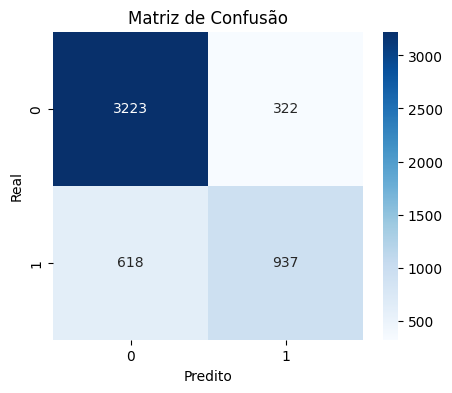

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

##**11. Comparação Antes x Depois**

| Métrica | Modelo Inicial | Modelo Otimizado |
| :--- | :--- | :--- |
| Accuracy | 0.8155 | 0.815686 |
| Precision | 0.7440 | 0.744241 |
| Recall | 0.6019 | 0.602572 |
| F1 | 0.6655 | 0.665956 |

Após a aplicação do GridSearchCV, o modelo otimizado foi avaliado utilizando o conjunto de teste. Os resultados obtidos foram:

- Accuracy: 81,57%
- Precision: 74,42%
- Recall: 60,26%
- F1-Score: 66,60%

Comparando esses resultados com os obtidos pelo modelo inicial, observa-se uma pequena melhoria em todas as métricas avaliadas. Embora o ganho seja discreto, ele demonstra que a otimização dos hiperparâmetros permitiu obter um modelo ligeiramente mais eficiente, mantendo boa capacidade de generalização.

##**12. Conclusão**

Neste projeto, foi desenvolvido um modelo de Machine Learning para prever o nível de estresse de estudantes a partir de informações relacionadas ao estilo de vida e ao contexto acadêmico.

Inicialmente, foram realizados o pré-processamento dos dados e a divisão entre conjuntos de treinamento e teste. Em seguida, foram avaliados quatro algoritmos de classificação: Regressão Logística, Árvore de Decisão, Random Forest e K-Nearest Neighbors (KNN).

A comparação das métricas mostrou que a **Regressão Logística** apresentou o melhor desempenho geral, alcançando 81,57% de acurácia, 74,42% de precisão, 60,26% de recall e 66,60% de F1-Score após a otimização por GridSearchCV. Embora a melhoria obtida com a otimização tenha sido pequena, ela confirmou que o modelo já se encontrava próximo da configuração ideal para este conjunto de dados.

Os resultados indicam que características relacionadas ao estilo de vida dos estudantes possuem potencial para auxiliar na identificação de níveis elevados de estresse. Como trabalhos futuros, podem ser exploradas técnicas de engenharia de atributos, balanceamento de classes e algoritmos mais avançados, visando melhorar ainda mais o desempenho preditivo do modelo.